In [8]:
!pip install matplotlib

In [3]:
!pip install nltk pandas scikit-learn

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --------------------------------- ------ 1.3/1.6 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 9.1 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [regex]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ---------------------------------------- 4/4 [nltk]



In [1]:
import pandas as pd

# wczytuje plik
df = pd.read_csv('IMDB_Dataset.csv')

# podgląd pierwszych 5 wierszy
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # małe litery
    text = text.lower()

    # usuwam tagi HTML
    text = re.sub(r'<br />', ' ', text)

    # usuwam znaki interpunkcyjne
    text = re.sub(r'[^\w\s]', '', text)

    # usuwam stopwords
    words = text.split()
    cleaned = [w for w in words if w not in stop_words]
    return " ".join(cleaned)

# czyszczenie kolumny 'review'
df['review_cleaned'] = df['review'].apply(clean_text)
df[['review', 'review_cleaned']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Raphael\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,review,review_cleaned
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [5]:
from sklearn.model_selection import train_test_split

# zamiana etykiety 'positive'/'negative' na 1/0
if df['sentiment'].dtype == 'O':
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    df['review_cleaned'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=43
)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# tworzenie pipeline
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        # liczba słów do nauki
        max_features=15000,
        # wprowadzam do modelu pojedyncze słowa oraz pary słów KLUCZ
        ngram_range=(1, 3),
        # ignorowanie słowa, które wystąpiło tylko raz
        min_df=2
    )),
    ('clf', LogisticRegression(C=0.5, max_iter=1000))
])

# trening modelu
model_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [18]:
score = model_pipeline.score(X_test, y_test)
print(f"Dokładność modelu: {score:.2%}")

Dokładność modelu: 89.52%


In [19]:
def predict_sentiment(text):
    # czyszczenie wpisanego tekstu
    cleaned = clean_text(text)
    # predykcja przez pipeline
    prediction = model_pipeline.predict([cleaned])[0]
    # prawdopodobieństwo
    proba = model_pipeline.predict_proba([cleaned])[0]
    
    sentiment = "positive" if prediction == 1 else "negative"
    confidence = proba[prediction] * 100
    
    print(f"review: {text}")
    print(f"verdict: {sentiment} (confidence: {confidence:.2f}%)")

# TEST
predict_sentiment("It turned out better than before, I think. We finally have flesh-and-blood characters instead of paper cutouts, but in return: that melancholic drowsiness has dissipated.")
predict_sentiment("the magic of cinema that never gets old")
predict_sentiment("A candidate for cinematic trash of the year. I didn't finish the book; from the moment the main character meets the alien, it started to irritate me terribly, and I gave up. But that was years ago, maybe I misread something, or misunderstood something. And fresh from watching it, I admit I wasn't wrong then.")

review: It turned out better than before, I think. We finally have flesh-and-blood characters instead of paper cutouts, but in return: that melancholic drowsiness has dissipated.
verdict: negative (confidence: 77.28%)
review: the magic of cinema that never gets old
verdict: positive (confidence: 56.72%)
review: A candidate for cinematic trash of the year. I didn't finish the book; from the moment the main character meets the alien, it started to irritate me terribly, and I gave up. But that was years ago, maybe I misread something, or misunderstood something. And fresh from watching it, I admit I wasn't wrong then.
verdict: negative (confidence: 83.23%)


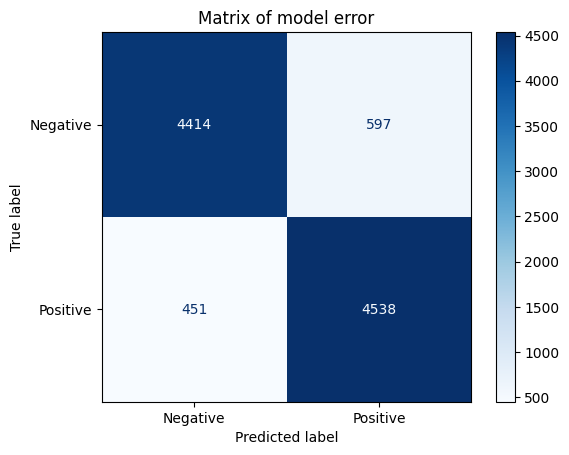

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrix of model error")
plt.show()

In [20]:
import numpy as np

# pobieramy nazwy słów (cech)
feature_names = model_pipeline.named_steps['tfidf'].get_feature_names_out()
# pobieram wagi (współczynniki) modelu
coefs = model_pipeline.named_steps['clf'].coef_[0]

# tworzę listę par (słowo, waga)
word_importances = pd.DataFrame({'word': feature_names, 'weight': coefs})

print("top 10 positive words:")
print(word_importances.sort_values(by='weight', ascending=False).head(10))

print("\ntop 10 negative words:")
print(word_importances.sort_values(by='weight', ascending=True).head(10))

top 10 positive words:
            word    weight
5829       great  6.535147
4345   excellent  5.434303
9913     perfect  4.362220
1354        best  4.235691
14680  wonderful  4.029400
641      amazing  3.885427
7823       loved  3.852358
4624    favorite  3.510428
180          710  3.402044
1710   brilliant  3.394350

top 10 negative words:
           word    weight
14744     worst -7.694786
1105        bad -7.433890
1060      awful -5.925975
1611     boring -5.424758
14327     waste -5.185111
10206      poor -5.001860
9235    nothing -4.990602
13206  terrible -4.854416
14740     worse -4.079966
6342   horrible -3.831948
